In [24]:
import os
import torch
from torch.utils.cpp_extension import load
DEVICE = triton.runtime.driver.active.get_active_torch_device()
a = torch.randn(32, 64, device=DEVICE, dtype=torch.float)
b = torch.randn(64, 128, device=DEVICE, dtype=torch.float)

In [15]:
this_dir = os.getcwd()
ext = load(
    name=f"matmul_ext",
    sources=[
        os.path.join(this_dir, "matmul.cpp"),
        os.path.join(this_dir, "matmul_kernel.cu"),
    ],
    verbose=True,
)

def cuda_matmul(a, b):
    return ext.matmul_cuda(a, b)

def matmul_cuda_coal(a, b):
    return ext.matmul_cuda_coal(a, b)

out = cuda_matmul(a, b)
out = matmul_cuda_coal(a, b)
out.shape

torch.Size([32, 128])

In [10]:
out1 = torch.matmul(a,b)

In [16]:
print(out1[1,1])

tensor(-14.6581, device='cuda:0')


In [17]:
print(out[1,1])

tensor(-14.6581, device='cuda:0')


In [39]:
import triton
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],
        x_vals=[128 * i for i in range(10, 751, 20)],
        line_arg='provider',
        line_vals=['torch', 'cuda', 'cuda_coal'],
        line_names=['Torch', 'CUDA naive', 'CUDA coalesced'],
        styles=[('green', '-'), ('red', '-'), ('blue', '-'), ('black', '-.')],
        ylabel='TFLOPs',
        plot_name='matmul-performance',
        args={'M': 1024, 'K': 256},
    ))
def benchmark(M, N, K, provider):
    """
    Benchmark matrix multiplication for several implementations.

    a is M by K
    b is K by N
    """

    a = torch.randn(M, K, device=DEVICE, dtype=torch.float32)
    b = torch.randn(K, N, device=DEVICE, dtype=torch.float32)

    # warmup
    for _ in range(5):
        if provider == 'torch':
            torch.matmul(a, b)
        elif provider == 'cuda':
            cuda_matmul(a, b)
        elif provider == 'cuda_coal':
            matmul_cuda_coal(a, b)
        else:
            triton_matmul(a, b)
    torch.cuda.synchronize()

    quantiles = [0.5, 0.2, 0.8]

    stream = getattr(torch, DEVICE.type).Stream()
    getattr(torch, DEVICE.type).set_stream(stream)

    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: torch.matmul(a, b),
            quantiles=quantiles
        )
    elif provider == 'cuda':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: cuda_matmul(a, b),
            quantiles=quantiles
        )
    elif provider == 'cuda_coal':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: matmul_cuda_coal(a, b),
            quantiles=quantiles
        )
    else:
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: triton_matmul(a, b),
            quantiles=quantiles
        )

    # FLOPs for matmul
    # Matmul does 2 * M * N * K floating point operations
    flops = 2.0 * M * N * K
    tflops = lambda ms: flops * 1e-12 / (ms * 1e-3)

    return tflops(ms), tflops(max_ms), tflops(min_ms)


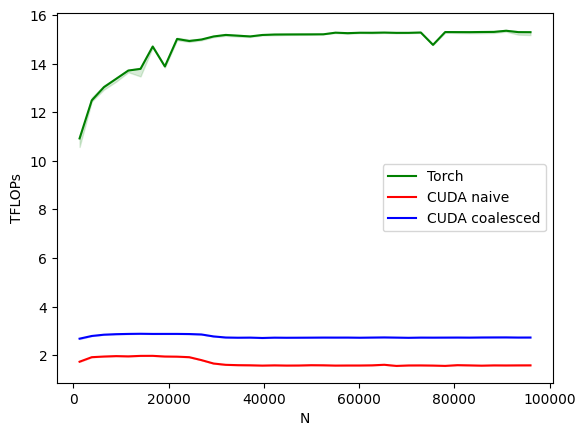

matmul-performance:
          N      Torch  CUDA naive  CUDA coalesced
0    1280.0  10.922667    1.738211        2.685902
1    3840.0  12.488003    1.924081        2.796700
2    6400.0  13.032264    1.951057        2.849391
3    8960.0  13.374694    1.968549        2.870789
4   11520.0  13.716838    1.957597        2.881363
5   14080.0  13.783862    1.978004        2.887518
6   16640.0  14.703760    1.979738        2.881221
7   19200.0  13.884746    1.951868        2.881983
8   21760.0  15.014986    1.945845        2.881821
9   24320.0  14.930264    1.924262        2.876378
10  26880.0  14.991895    1.803736        2.858862
11  29440.0  15.118636    1.663261        2.777973
12  32000.0  15.181572    1.609905        2.733856
13  34560.0  15.149588    1.595986        2.725213
14  37120.0  15.119681    1.590946        2.729490
15  39680.0  15.179190    1.578445        2.714539
16  42240.0  15.197922    1.588287        2.727911
17  44800.0  15.200531    1.579725        2.723761
18  47360.0

In [40]:
benchmark.run(show_plots=True, print_data=True)